<a href="https://colab.research.google.com/github/gnn59lll-coder/Laboratory-works-for-II/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [64]:
df = pd.read_csv('/content/sample_data/Air_Quality_and_Health_Impacts.csv', sep=',')

In [65]:
print("Размер датасета:", df.shape)
print(df.shape)


Размер датасета: (18862, 12)
(18862, 12)


In [66]:
print("Первые 7 строк:")
print(df.head(7))

Первые 7 строк:
   Unique ID  Indicator ID                     Name Measure Measure Info  \
0     878218           386               Ozone (O3)    Mean          ppb   
1     878245           386               Ozone (O3)    Mean          ppb   
2     743686           386               Ozone (O3)    Mean          ppb   
3     827060           386               Ozone (O3)    Mean          ppb   
4     825775           375   Nitrogen dioxide (NO2)    Mean          ppb   
5     222575           386               Ozone (O3)    Mean          ppb   
6     874551           365  Fine particles (PM 2.5)    Mean       mcg/m3   

  Geo Type Name  Geo Join ID      Geo Place Name          Time Period  \
0         UHF42          402         West Queens          Summer 2023   
1         UHF42          103  Fordham - Bronx Pk          Summer 2023   
2         UHF42          503         Willowbrook          Summer 2021   
3         UHF34          407    Southwest Queens          Summer 2022   
4         

Unique ID — Уникальный идентификатор

Indicator ID — Идентификатор показателя

Name — Название (тип загрязнителя: Ozone, NO2, PM2.5 и т.д.)

Measure — Тип измерения (Mean - среднее)

Measure Info — Информация об измерении (единицы измерения: ppb, mcg/m3)

Geo Type Name — Тип географической области (UHF42, CD, Borough, Citywide)

Geo Join ID — Идентификатор географической области

Geo Place Name — Название географической области (район, округ)

Time Period — Временной период (Summer 2023, Annual Average 2023, Winter 2022-23)

Start_Date — Дата начала периода

Data Value — Значение данных (концентрация загрязнителя) — целевая переменная

Message — Сообщение (обычно пустое)



In [67]:
print("Информация о колонках:")
print(df.info())

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB
None


In [68]:
print("Статистика числовых колонок:")
print(df.describe())

Статистика числовых колонок:
           Unique ID  Indicator ID   Geo Join ID    Data Value  Message
count   18862.000000  18862.000000  1.886200e+04  18862.000000      0.0
mean   452004.167533    431.817888  5.983262e+05     21.051580      NaN
std    262910.731230    113.946565  7.819721e+06     23.564920      NaN
min    130355.000000    365.000000  1.000000e+00      0.000000      NaN
25%    176073.250000    365.000000  2.020000e+02      8.742004      NaN
50%    412490.500000    375.000000  3.030000e+02     14.790000      NaN
75%    669588.750000    386.000000  4.040000e+02     26.267500      NaN
max    878254.000000    661.000000  1.051061e+08    424.700000      NaN


In [69]:
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           18862
dtype: int64


In [70]:
df = df.drop(columns=['Message'])

In [71]:
print(df.head(5))

   Unique ID  Indicator ID                    Name Measure Measure Info  \
0     878218           386              Ozone (O3)    Mean          ppb   
1     878245           386              Ozone (O3)    Mean          ppb   
2     743686           386              Ozone (O3)    Mean          ppb   
3     827060           386              Ozone (O3)    Mean          ppb   
4     825775           375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name  Geo Join ID      Geo Place Name  Time Period  Start_Date  \
0         UHF42          402         West Queens  Summer 2023  06/01/2023   
1         UHF42          103  Fordham - Bronx Pk  Summer 2023  06/01/2023   
2         UHF42          503         Willowbrook  Summer 2021  06/01/2021   
3         UHF34          407    Southwest Queens  Summer 2022  06/01/2022   
4         UHF42          201          Greenpoint  Summer 2022  06/01/2022   

   Data Value  
0   34.365989  
1   32.310518  
2   29.086208  
3   35.155608  
4   14

In [72]:
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
Unique ID         0
Indicator ID      0
Name              0
Measure           0
Measure Info      0
Geo Type Name     0
Geo Join ID       0
Geo Place Name    0
Time Period       0
Start_Date        0
Data Value        0
dtype: int64


In [73]:
df_clean = df.copy()

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

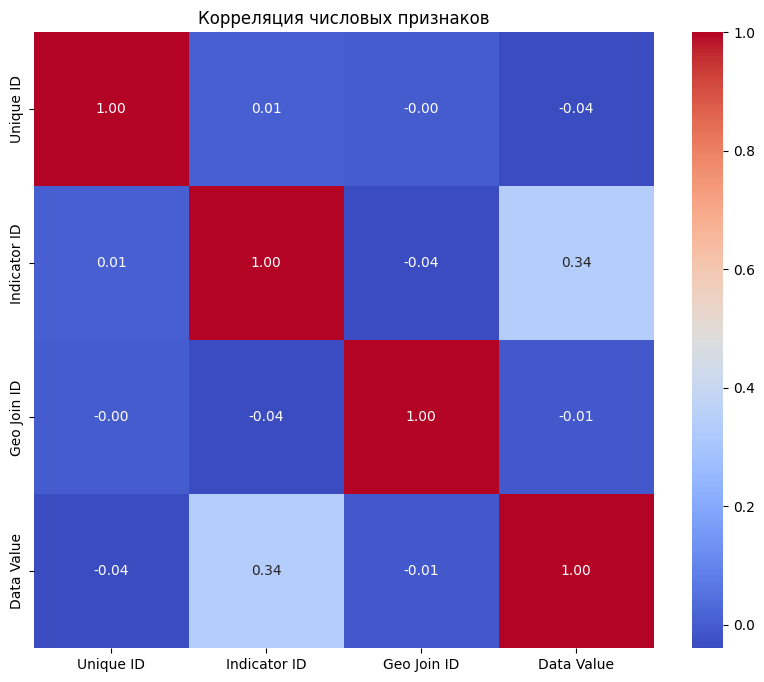

In [75]:
numeric_data = df_clean[numeric_cols].select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

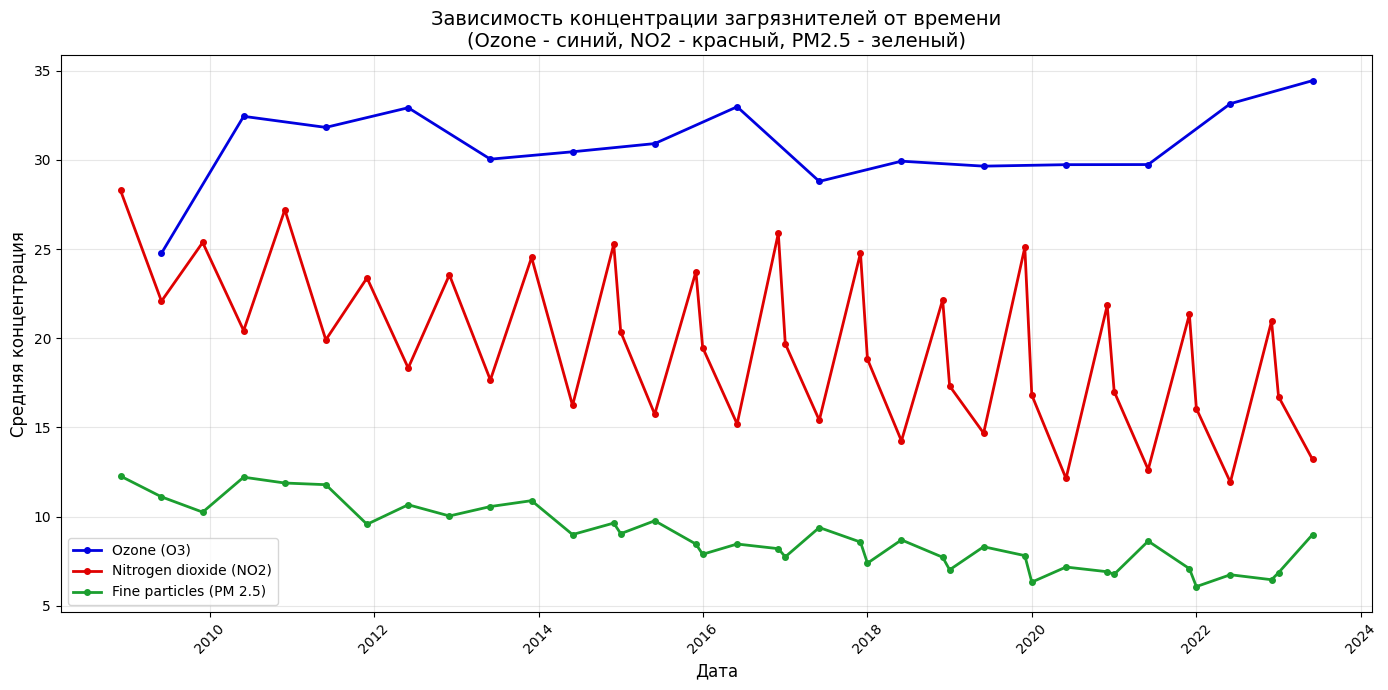

In [80]:
df_line = df_clean.copy()
df_line['Start_Date'] = pd.to_datetime(df_line['Start_Date'], errors='coerce')
df_line = df_line.dropna(subset=['Start_Date', 'Data Value'])

pollutants = ['Ozone (O3)', 'Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)']
df_line = df_line[df_line['Name'].isin(pollutants)]

# Агрегация: среднее значение по дате для каждого загрязнителя
df_grouped = df_line.groupby(['Start_Date', 'Name'])['Data Value'].mean().reset_index()

# Цвета для загрязнителей
colors = {'Ozone (O3)': '#0101DF', 'Nitrogen dioxide (NO2)': '#DF0101', 'Fine particles (PM 2.5)': '#1B9E2F'}

# Построение линейного графика
plt.figure(figsize=(14, 7))

for pollutant in pollutants:
    df_poll = df_grouped[df_grouped['Name'] == pollutant].sort_values('Start_Date')
    plt.plot(df_poll['Start_Date'], df_poll['Data Value'],
             color=colors[pollutant], label=pollutant, linewidth=2, marker='o', markersize=4)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Средняя концентрация', fontsize=12)
plt.title('Зависимость концентрации загрязнителей от времени\n(Ozone - синий, NO2 - красный, PM2.5 - зеленый)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

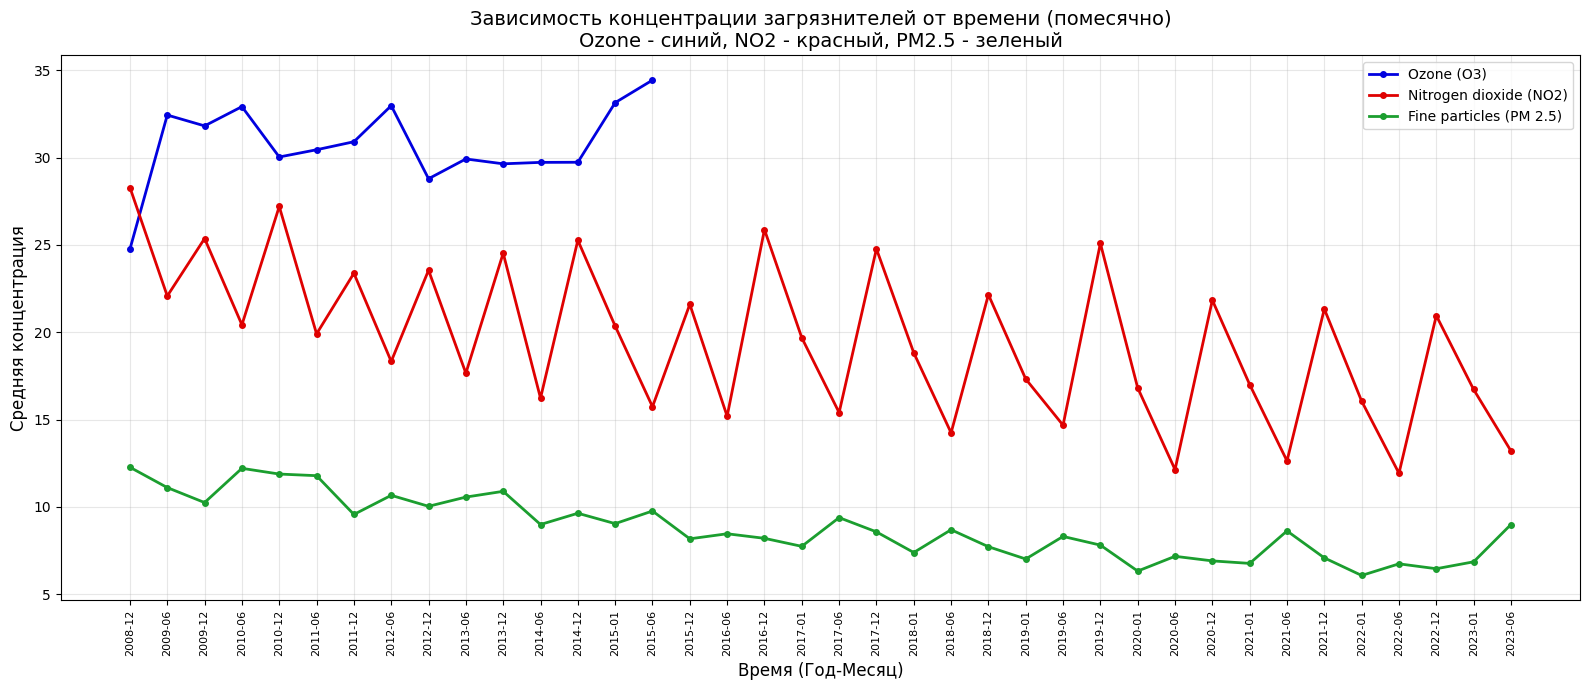

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Подготовка данных
df_line = df_clean.copy()
df_line['Start_Date'] = pd.to_datetime(df_line['Start_Date'], errors='coerce')
df_line = df_line.dropna(subset=['Start_Date', 'Data Value'])

# Создаем колонку с годом и месяцем
df_line['Year_Month'] = df_line['Start_Date'].dt.to_period('M').astype(str)

# Фильтруем только нужные загрязнители
pollutants = ['Ozone (O3)', 'Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)']
df_line = df_line[df_line['Name'].isin(pollutants)]

# Группировка по году-месяцу и типу загрязнителя
df_grouped = df_line.groupby(['Year_Month', 'Name'])['Data Value'].mean().reset_index()
df_grouped = df_grouped.sort_values('Year_Month')

# Цвета для загрязнителей
colors = {'Ozone (O3)': '#0101DF', 'Nitrogen dioxide (NO2)': '#DF0101', 'Fine particles (PM 2.5)': '#1B9E2F'}

# Построение графика
plt.figure(figsize=(16, 7))

for pollutant in pollutants:
    df_poll = df_grouped[df_grouped['Name'] == pollutant]
    plt.plot(range(len(df_poll)), df_poll['Data Value'],
             color=colors[pollutant], label=pollutant, linewidth=2, marker='o', markersize=4)

# Настройка подписей оси X (месяц-год)
months = df_grouped['Year_Month'].unique()
plt.xticks(range(len(months)), months, rotation=90, fontsize=8)

plt.xlabel('Время (Год-Месяц)', fontsize=12)
plt.ylabel('Средняя концентрация', fontsize=12)
plt.title('Зависимость концентрации загрязнителей от времени (помесячно)\nOzone - синий, NO2 - красный, PM2.5 - зеленый', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Linear Regression    | MSE: 423.3335 | MAE: 9.7249 | R2: 0.2720
Ridge Regression     | MSE: 423.3335 | MAE: 9.7249 | R2: 0.2720
Lasso Regression     | MSE: 425.3243 | MAE: 9.8149 | R2: 0.2686
Decision Tree        | MSE: 57.2849 | MAE: 2.3135 | R2: 0.9015
Random Forest        | MSE: 30.9628 | MAE: 1.9131 | R2: 0.9468
Gradient Boosting    | MSE: 139.4718 | MAE: 4.7945 | R2: 0.7602
XGBoost              | MSE: 18.7109 | MAE: 1.7549 | R2: 0.9678
KNN                  | MSE: 213.0716 | MAE: 5.2977 | R2: 0.6336


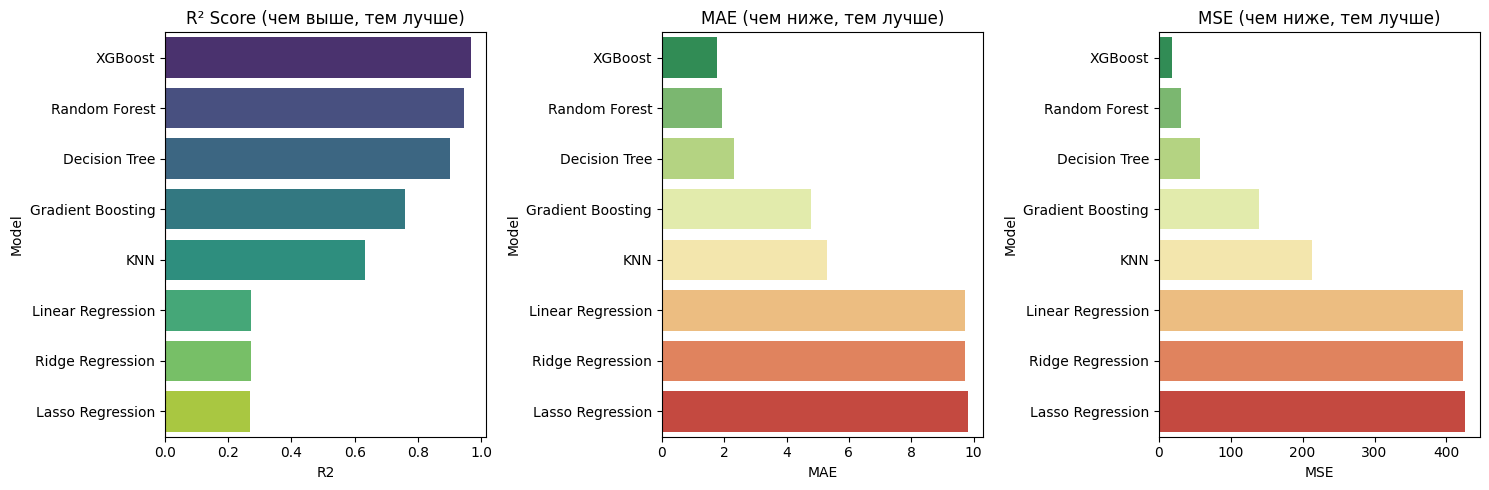

In [85]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Выбираем признаки
feature_cols = [col for col in df_model.columns if col not in ['Data Value', 'Start_Date']]
X = df_model[feature_cols].fillna(0)
y = df_model['Data Value']

# Разделение
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================================
# 2. ОБУЧЕНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ
# ============================================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    })

    print(f"{name:20} | MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

# ============================================
# 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R2 Score
sns.barplot(data=results_df, x='R2', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('R² Score (чем выше, тем лучше)')
axes[0].axvline(x=0, color='red', linestyle='--')

# MAE
sns.barplot(data=results_df, x='MAE', y='Model', palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('MAE (чем ниже, тем лучше)')

# MSE
sns.barplot(data=results_df, x='MSE', y='Model', palette='RdYlGn_r', ax=axes[2])
axes[2].set_title('MSE (чем ниже, тем лучше)')

plt.tight_layout()
plt.show()


In [89]:
# Функция предсказания для регрессии (ваша задача)
def predict_air_quality(model, scaler, feature_names, features_dict):
    """
    Принимает обученную модель, скейлер, список признаков и словарь с новыми данными.
    Возвращает предсказанную концентрацию загрязнителя.
    """
    import pandas as pd

    # Создаем DataFrame из словаря
    new_df = pd.DataFrame([features_dict])

    # Добавляем недостающие колонки с 0
    missing = set(feature_names) - set(new_df.columns)
    for col in missing:
        new_df[col] = 0

    # Приводим порядок колонок к обученному
    new_df = new_df[feature_names]

    # Масштабируем
    new_scaled = scaler.transform(new_df)

    # Предсказываем
    prediction = model.predict(new_scaled)[0]

    return prediction

In [88]:
# ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЯ С ВИЗУАЛИЗАЦИЕЙ
def predict_and_visualize(model, scaler, feature_names, features_dict, actual_value=None):
    """
    Предсказывает концентрацию и показывает результат с визуализацией
    """
    predicted = predict_air_quality(model, scaler, feature_names, features_dict)

    print("-" * 50)
    print("📊 РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
    print("-" * 50)
    print(f"🎯 Предсказанная концентрация: {predicted:.2f}")

    if actual_value is not None:
        error = abs(predicted - actual_value)
        error_pct = (error / actual_value) * 100
        print(f"📌 Реальная концентрация: {actual_value:.2f}")
        print(f"📈 Ошибка: {error:.2f} ({error_pct:.1f}%)")

    # Визуализация
    fig, ax = plt.subplots(figsize=(8, 4))

    # Шкала концентрации
    ax.barh(['Концентрация'], [predicted], color='skyblue', edgecolor='navy', height=0.5)
    if actual_value:
        ax.scatter([actual_value], ['Концентрация'], color='red', s=100, zorder=5, label='Реальное значение')

    ax.set_xlabel('Концентрация загрязнителя')
    ax.set_title('Предсказание качества воздуха')
    if actual_value:
        ax.legend()

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return predicted

# Пример использования
test_data = {
    'Year': 2023,
    'Month': 7,
    'Day': 15,
    'DayOfWeek': 5,
    'WeekOfYear': 28,
    'Quarter': 3,
    'IsWeekend': 1,
    'Name_encoded': 0,
    'Measure_encoded': 0,
    'Geo Type Name_encoded': 0,
    'Geo Place Name_encoded': 50,
    'Time Period_encoded': 30,
}

# Добавляем недостающие признаки (заполняем 0)
for col in feature_names:
    if col not in test_data:
        test_data[col] = 0

predicted_value = predict_and_visualize(final_xgb, scaler, feature_names, test_data)

NameError: name 'feature_names' is not defined